<h1><center>Hand Gesture Classification using HaGRID dataset & MediaPipe</center></h1>


In [18]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# reading the dataset & displaying the first few rows
df = pd.read_csv('hand_landmarks_data.csv')
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [4]:
df['label'].unique()

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

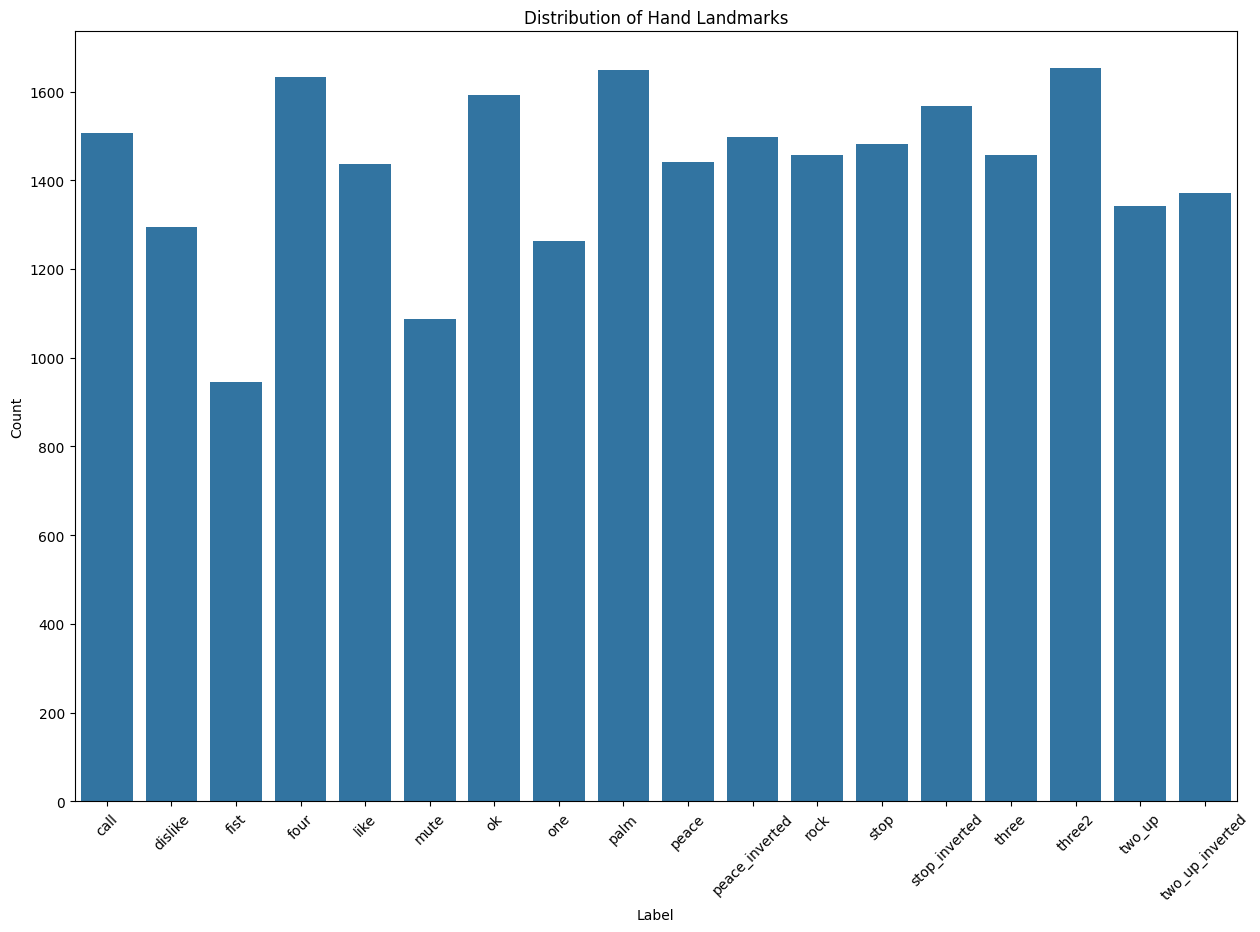

In [5]:
# checking the distribution of the 'label' column
fig = plt.figure(figsize=(15, 10))
sns.countplot(x='label', data=df)
plt.title('Distribution of Hand Landmarks')
plt.xlabel('Label')
plt.ylabel('Count') 
plt.xticks(rotation=45)
plt.show()

In [6]:
df['label'].value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

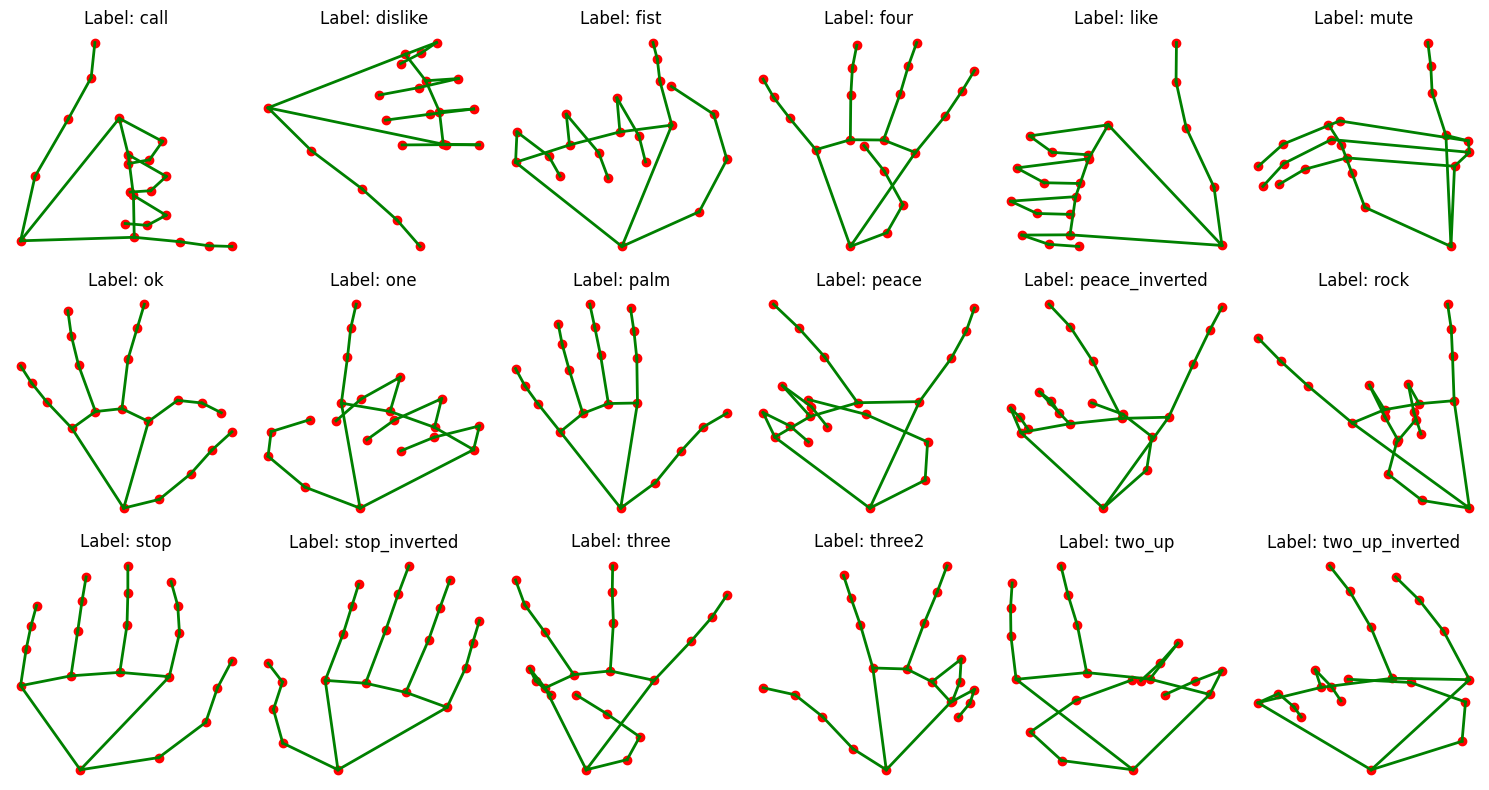

In [7]:

# Select one row per label
sampled_df = df.groupby("label").sample().reset_index()

# Number of landmarks
num_landmarks = 21

# Define hand landmark edges (MediaPipe structure)
edges = [
    (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),  # Index
    (0, 17), (17, 18), (18, 19), (19, 20),  # Pinky
    (5, 9), (9, 10), (10, 11), (11, 12),  # Middle
    (9, 13), (13, 14), (14, 15), (15, 16),  # Ring
    (13, 17)  # Palm base connection
]

# Plot all sampled gestures
fig, axes = plt.subplots(3, 6, figsize=(15, 8))  # Adjust grid based on the number of labels
axes = axes.flatten() 

for i, row in sampled_df.iterrows():
    ax = axes[i]
    
    # Extract (x, y) coordinates
    x_values = [row[f"x{j+1}"] for j in range(num_landmarks)]
    y_values = [row[f"y{j+1}"] for j in range(num_landmarks)]

    # Plot hand landmarks
    ax.scatter(x_values, y_values, color='red', label="Landmarks")

    # Draw edges
    for edge in edges:
        x_start, y_start = x_values[edge[0]], y_values[edge[0]]
        x_end, y_end = x_values[edge[1]], y_values[edge[1]]
        ax.plot([x_start, x_end], [y_start, y_end], color="green", linewidth=2)

    # Annotate gesture label
    ax.set_title(f"Label: {row['label']}")
    ax.invert_yaxis()  # Invert y-axis for correct orientation
    ax.axis("off")  # Hide axis for better visualization

plt.tight_layout()
plt.show()


In [8]:
# Process each row in the dataset
def normalize_landmarks(row):
    # Wrist coordinates (Landmark 0)
    wrist_x, wrist_y = row["x1"], row["y1"]
    # Middle fingertip coordinates (Landmark 12)
    mid_finger_x, mid_finger_y = row["x13"], row["y13"]
    # Compute scaling factor (distance from wrist to middle fingertip)
    scale = np.sqrt((mid_finger_x - wrist_x) ** 2 + (mid_finger_y - wrist_y) ** 2)
    
    # Avoid division by zero
    if scale == 0:
        scale = 1
    # Normalize each landmark
    for i in range(num_landmarks):
        row[f"x{i+1}"] = (row[f"x{i+1}"] - wrist_x) / scale
        row[f"y{i+1}"] = (row[f"y{i+1}"] - wrist_y) / scale

    return row

# Apply normalization
df_normalized = df.apply(normalize_landmarks, axis=1)

In [17]:
df_normalized.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,0.0,0.0,-3.649205e-07,-0.169097,-0.328246,0.004224,-0.508248,-0.501843,0.005798,-0.846234,...,-1.266027,-0.058407,-0.020450,-1.533293,0.026072,-0.024577,-1.759842,0.074168,-0.026722,call
1,0.0,0.0,-2.345265e-07,-0.040618,-0.498120,-0.011102,0.191551,-0.982869,-0.021096,0.349889,...,1.397837,-0.121412,-0.038175,1.691695,-0.091952,-0.037336,1.966655,-0.086635,-0.036136,call
2,0.0,0.0,-2.417307e-07,0.172978,-0.420554,-0.000184,0.437913,-0.820949,-0.009687,0.621006,...,1.404373,0.187884,-0.044068,1.676609,0.247919,-0.040469,1.913833,0.270275,-0.038301,call
3,0.0,0.0,-1.233261e-07,-0.020056,-0.468103,-0.002824,0.070355,-0.911821,-0.008911,0.114792,...,1.280797,-0.094800,-0.027622,1.529073,-0.079763,-0.027863,1.738331,-0.086693,-0.027723,call
4,0.0,0.0,-1.622995e-07,-0.009611,-0.482677,-0.002884,0.111650,-1.075914,-0.008115,0.131602,...,1.327537,-0.331511,-0.025113,1.612488,-0.386821,-0.024087,1.849127,-0.464123,-0.023486,call


In [ ]:
label_encoder = LabelEncoder()

df_normalized["label_encoded"] = label_encoder.fit_transform(df_normalized["label"])

# Check encoding
print(df_normalized[["label", "label_encoded"]].head())

#decoded_label = label_encoder.inverse_transform([0])  # Converts 0 back to original label


  label  label_encoded
0  call              0
1  call              0
2  call              0
3  call              0
4  call              0


In [21]:
df_normalized.drop(columns=["label"], inplace=True)
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   x1             25675 non-null  float64
 1   y1             25675 non-null  float64
 2   z1             25675 non-null  float64
 3   x2             25675 non-null  float64
 4   y2             25675 non-null  float64
 5   z2             25675 non-null  float64
 6   x3             25675 non-null  float64
 7   y3             25675 non-null  float64
 8   z3             25675 non-null  float64
 9   x4             25675 non-null  float64
 10  y4             25675 non-null  float64
 11  z4             25675 non-null  float64
 12  x5             25675 non-null  float64
 13  y5             25675 non-null  float64
 14  z5             25675 non-null  float64
 15  x6             25675 non-null  float64
 16  y6             25675 non-null  float64
 17  z6             25675 non-null  float64
 18  x7    

In [22]:
df_normalized['label_encoded'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

In [24]:
label_encoder.inverse_transform(df_normalized['label_encoded'].unique())

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

In [25]:
features = df_normalized.drop(["label_encoded"], axis=1)
labels = df_normalized["label_encoded"]

In [26]:
features.shape

(25675, 63)

In [27]:
labels.shape

(25675,)

In [28]:
# Splitting the dataset into training and validation/test sets
# 60% training, 40% validation/test
features_train, features_validation_test, labels_train, labels_validation_test = train_test_split(
    features, labels, test_size=0.4, random_state=100)

In [29]:
# Splitting the validation/test set into two equal parts
features_validation, features_test, labels_validation, labels_test = train_test_split(
    features_validation_test, labels_validation_test, test_size=0.5, random_state=100)

In [30]:
print(len(features_train))
print(len(features_validation))
print(len(features_test))
print(len(labels_train))
print(len(labels_validation))
print(len(labels_test))

15405
5135
5135
15405
5135
5135
